In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

card_df = pd.read_csv('../data/creditcard.csv')
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [62]:
card_df.shape

(284807, 31)

In [63]:
card_df.value_counts()

Time      V1          V2          V3         V4         V5         V6         V7          V8          V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21         V22        V23        V24        V25        V26        V27        V28        Amount  Class
163152.0  -1.196037    1.585949    2.883976   3.378471   1.511706   3.717077   0.585362   -0.156001    0.122648   4.217934   1.385525  -0.709405  -0.256168  -1.564352   1.693218  -0.785210  -0.228008  -0.412833   0.234834   1.375790  -0.370294    0.524395  -0.355170  -0.869790  -0.133198   0.327804  -0.035702  -0.858197  7.56    0        18
          -1.203617    1.574009    2.889277   3.381404   1.538663   3.698747   0.560211   -0.150911    0.124136   4.220998   1.384569  -0.706897  -0.256274  -1.562583   1.692915  -0.787338  -0.226776  -0.412354   0.234322   1.385597  -0.366727    0.522223  -0.357329  -0.870174  -0.134166   0.327019  -0.042648  -0.85526

In [64]:
from sklearn.model_selection import train_test_split

# 인자로 입력받은 DataFrame을 복사한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

In [65]:
# 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수.
def get_train_test_dataset(df=None):
    # 인자로 입력된 DataFrame의 사전 데이터 가공이 완료된 복사 DataFrame 반환
    df_copy = get_preprocessed_df(df)
    # DataFrame의 맨 마지막 컬럼이 레이블, 나머지는 피처들
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    # train_test_split( )으로 학습과 테스트 데이터 분할. stratify=y_target으로 Stratified 기반 분할
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    # 학습과 테스트 데이터 세트 반환
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [66]:
# 분포 확인
print(f'학습데이터 사기 거래 비율 : {y_train.value_counts()/y_train.shape[0]*100}')
print(f'테스트 데이터 사기 거래 비율 : {y_test.value_counts()/y_test.shape[0]*100}')

학습데이터 사기 거래 비율 : 0    99.827451
1     0.172549
Name: Class, dtype: float64
테스트 데이터 사기 거래 비율 : 0    99.826785
1     0.173215
Name: Class, dtype: float64


In [67]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [68]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
lr_pred_proba

array([0.0015387 , 0.00013517, 0.00018654, ..., 0.00030772, 0.00087699,
       0.00015642])

In [69]:
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85283    12]
 [   61    87]]
정확도: 0.9991, 정밀도: 0.8788, 재현율: 0.5878,    F1: 0.7045, AUC:0.9586


LGBM 모델 생성

In [70]:
def get_model_train_eval(model, ftr_train=None, ftr_test = None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [71]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

오차 행렬
[[85290     5]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568,    F1: 0.8453, AUC:0.9790


# 피처 특성을 파악, 전처리
1. Amount 피처

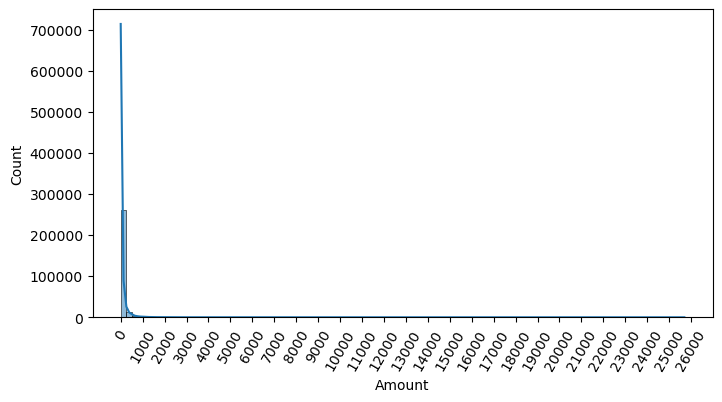

In [72]:
import seaborn as sns
plt.figure(figsize=(8, 4))
plt.xticks(range(0,30000,1000), rotation = 60)
sns.histplot(card_df['Amount'], bins = 100, kde=True)
plt.show()

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 인자로 입력받은 DataFrame을 복사한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)

    # Amount scaling
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))

    df_copy.insert(0, 'Amount_scaled', amount_n)
    return df_copy

In [74]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [75]:
# logistic regression 모델 생성
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85283    12]
 [   58    90]]
정확도: 0.9992, 정밀도: 0.8824, 재현율: 0.6081,    F1: 0.7200, AUC:0.9649


In [76]:
get_model_train_eval(lr_clf, X_train, X_test,y_train,y_test)

오차 행렬
[[85283    12]
 [   58    90]]
정확도: 0.9992, 정밀도: 0.8824, 재현율: 0.6081,    F1: 0.7200, AUC:0.9649


In [77]:

# 인자로 입력받은 DataFrame을 복사한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)

    # Amount scaling
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)

    return df_copy

In [78]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [79]:
from sklearn.linear_model import LogisticRegression
lr_clf =LogisticRegression()
get_model_train_eval(lr_clf, X_train, X_test,y_train,y_test)

오차 행렬
[[85271    24]
 [   54    94]]
정확도: 0.9991, 정밀도: 0.7966, 재현율: 0.6351,    F1: 0.7068, AUC:0.9286


# 이상치 탐색
상관관계 - target

In [80]:
import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
    # fraud에 해당하는 column 데이터만 추출
    fraud = df[df['Class']==1][column]

    # 1/4 분위와 3/4 분위 지점을 np.percentile로 구함. 
    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)

    # IQR을 구하고, IQR에 1.5를 곱하여 최대값과 최소값 지점 구함. 
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    
    # 최대값 보다 크거나, 최소값 보다 작은 값을 아웃라이어로 설정하고 해당 이상치 데이터의 DataFrame index 반환. 
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index
    

In [81]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
outlier_index

Int64Index([8296, 8615, 9035, 9252], dtype='int64')

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 인자로 입력받은 DataFrame을 복사한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)

    # Amount scaling
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))

    df_copy.insert(0, 'Amount_scaled', amount_n)

    df_copy.drop(outlier_index, axis= 0 , inplace=True)
    return df_copy

In [83]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [84]:
lr_clf =LogisticRegression()
get_model_train_eval(lr_clf, X_train, X_test,y_train,y_test)

오차 행렬
[[85282    13]
 [   54    92]]
정확도: 0.9992, 정밀도: 0.8762, 재현율: 0.6301,    F1: 0.7331, AUC:0.9584


In [85]:
# V17 처리
# 데이터 전처리 함수 수정
def get_preprocessed_df(df=None):
    # 복사본을 만들어 Time 컬럼 삭제
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    
    # V17 컬럼의 결측치 처리 (평균값값 대체)
    if df_copy['V17'].isnull().sum() > 0:
        df_copy['V17'].fillna(df_copy['V17'].mean(), inplace=True)
    
    # V17 컬럼의 이상치 처리 (Z-점수 방식으로 처리 예시)
    from scipy import stats
    z_scores = stats.zscore(df_copy['V17'])
    df_copy = df_copy[(z_scores > -3) & (z_scores < 3)]  # Z-점수가 -3에서 3 사이인 값만 남김
    
    # V17 컬럼 표준화
    scaler = StandardScaler()
    df_copy['V17'] = scaler.fit_transform(df_copy[['V17']])
    
    return df_copy

In [36]:
# 학습 및 테스트 데이터셋을 반환하는 함수
def get_train_test_dataset(df=None):
    df_copy = get_preprocessed_df(df)
    X_features = df_copy.iloc[:, :-1] 
    y_target = df_copy.iloc[:, -1]     
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    return X_train, X_test, y_train, y_test

In [37]:
# 데이터셋 분리
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [38]:
# 분포 확인
print(f'학습데이터 사기 거래 비율 : {y_train.value_counts()/y_train.shape[0]*100}')
print(f'테스트 데이터 사기 거래 비율 : {y_test.value_counts()/y_test.shape[0]*100}')

학습데이터 사기 거래 비율 : 0    99.956479
1     0.043521
Name: Class, dtype: float64
테스트 데이터 사기 거래 비율 : 0    99.95631
1     0.04369
Name: Class, dtype: float64


학습데이터 사기 거래 비율 : 0    99.827451
1     0.172549
Name: Class, dtype: float64
테스트 데이터 사기 거래 비율 : 0    99.826785
1     0.173215
Name: Class, dtype: float64

# LogisticRegression

In [39]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
lr_pred_proba

array([5.02377998e-05, 1.17966950e-04, 2.05097908e-04, ...,
       4.24860827e-04, 1.09331032e-04, 7.91421711e-04])

In [ ]:
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[84650     1]
 [   20    17]]
정확도: 0.9998, 정밀도: 0.9444, 재현율: 0.4595,    F1: 0.6182, AUC:0.8748


오차 행렬
[[85283    12]
 [   61    87]]
정확도: 0.9991, 정밀도: 0.8788, 재현율: 0.5878,    F1: 0.7045, AUC:0.9586

In [41]:
def get_model_train_eval(model, ftr_train=None, ftr_test = None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [42]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

오차 행렬
[[84650     1]
 [   20    17]]
정확도: 0.9998, 정밀도: 0.9444, 재현율: 0.4595,    F1: 0.6182, AUC:0.9329


오차 행렬
[[85290     5]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568,    F1: 0.8453, AUC:0.9790

In [ ]:
# SMOTE - 오버샘플링을 할 때 알고리즘

In [43]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print(f'X_train : {X_train.shape} y_train : {y_train.shape}')
print(f'X_train_over : {X_train_over.shape} y_train_over : {y_train_over.shape}')


X_train : (197604, 29) y_train : (197604,)
X_train_over : (395036, 29) y_train_over : (395036,)


In [45]:
print(f'y_train_over.value_counts() : ')
print(pd.Series(y_train_over).value_counts())

y_train_over.value_counts() : 
0    197518
1    197518
Name: Class, dtype: int64


In [46]:
lr_clf =LogisticRegression()
get_model_train_eval(lr_clf, X_train_over, X_test,y_train_over,y_test)

오차 행렬
[[76572  8079]
 [    6    31]]
정확도: 0.9045, 정밀도: 0.0038, 재현율: 0.8378,    F1: 0.0076, AUC:0.9488


오차 행렬
[[85282    13]
 [   54    92]]
정확도: 0.9992, 정밀도: 0.8762, 재현율: 0.6301,    F1: 0.7331, AUC:0.9584

In [47]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[84643     8]
 [   19    18]]
정확도: 0.9997, 정밀도: 0.6923, 재현율: 0.4865,    F1: 0.5714, AUC:0.9320


오차 행렬
[[85271    24]
 [   54    94]]
정확도: 0.9991, 정밀도: 0.7966, 재현율: 0.6351,    F1: 0.7068, AUC:0.9286

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출. 
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

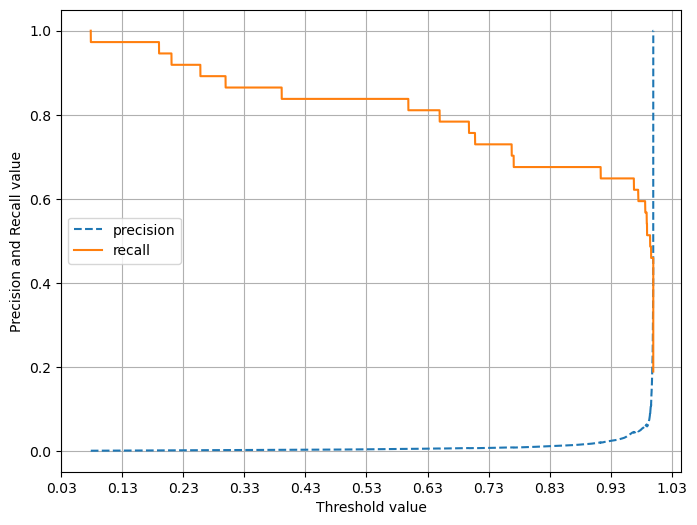

In [51]:
# LR의 SMOTE 이전 데이터터
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

# RF

In [90]:
from sklearn.ensemble import RandomForestClassifier

# 랜덤 포레스트 모델 학습
rf_model = RandomForestClassifier(random_state=0)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=0)

In [91]:
# 예측
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [92]:
get_clf_eval(y_test, rf_pred, rf_pred_proba)

오차 행렬
[[85288     7]
 [   32   114]]
정확도: 0.9995, 정밀도: 0.9421, 재현율: 0.7808,    F1: 0.8539, AUC:0.9609


# XGB

In [87]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=20,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [88]:
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

In [89]:
get_clf_eval(y_test, xgb_pred, xgb_pred_proba)

오차 행렬
[[85291     4]
 [   28   118]]
정확도: 0.9996, 정밀도: 0.9672, 재현율: 0.8082,    F1: 0.8806, AUC:0.9762


In [ ]:
# lr 결과
오차 행렬
[[85282    13]
 [   54    92]]
정확도: 0.9992, 정밀도: 0.8762, 재현율: 0.6301,    F1: 0.7331, AUC:0.9584

In [ ]:
# lgbm 결과
오차 행렬
[[85290     5]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568,    F1: 0.8453, AUC:0.9790

In [ ]:
# RF 결과
오차 행렬
[[85288     7]
 [   32   114]]
정확도: 0.9995, 정밀도: 0.9421, 재현율: 0.7808,    F1: 0.8539, AUC:0.9609

In [ ]:
# XGB 결과
오차 행렬
[[85291     4]
 [   28   118]]
정확도: 0.9996, 정밀도: 0.9672, 재현율: 0.8082,    F1: 0.8806, AUC:0.9762